In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
import numpy as np
import random
from typing import Dict

def load_feature_arrays(root_dir: str, feature_type: str) -> Dict[str, np.ndarray]:
    """
    从指定根目录加载特定feature_type的所有array
    
    参数:
        root_dir: 根目录路径
        feature_type: 特征类型，可以是"clip", "psd"或"rating"
    
    返回:
        一个字典，键是被试编号，值是对应的numpy array
    """
    feature_arrays = {}
    
    # 遍历根目录下的所有子目录
    for sub_dir in os.listdir(root_dir):
        sub_dir_path = os.path.join(root_dir, sub_dir)
        
        # 检查是否是目录
        if os.path.isdir(sub_dir_path):
            # 构建feature_type目录路径
            feature_dir = os.path.join(sub_dir_path, feature_type)
            
            # 检查feature_type目录是否存在
            if os.path.exists(feature_dir):
                npy_file = os.path.join(feature_dir, "all_viewed_image_rewards.npy")
                
                # 检查npy文件是否存在并加载
                if os.path.exists(npy_file):
                    try:
                        array = np.load(npy_file, allow_pickle=True)
                        feature_arrays[sub_dir] = array
                    except Exception as e:
                        print(f"Error loading {npy_file}: {e}")
                else:
                    print(f"File not found: {npy_file}")
    
    return feature_arrays

def extract_elements(subject_arrays: Dict[str, np.ndarray]) -> np.ndarray:
    """
    从每个被试的数组中提取三个特定元素并合并
    
    参数:
        subject_arrays: 包含所有被试数组的字典
    
    返回:
        合并后的numpy数组
    """
    result_list = []
    
    for sub_id, array in subject_arrays.items():
        if len(array) == 0:
            continue
            
        # 确保数组至少有10个元素
        first_10 = array[:10] if len(array) >= 10 else array
        
        # 1. 从前10个中随机选一个
        random_element = random.choice(first_10)
        
        # 2. 前10个中的最大值
        max_in_first_10 = np.max(first_10)
        
        # 3. 全局最大值
        global_max = np.max(array)
        
        # 将三个值组成小数组并添加到结果列表
        result_list.append(np.array([random_element, max_in_first_10, global_max]))
    
    # 将所有被试的小数组合并成一个大的numpy数组
    if result_list:
        return np.vstack(result_list)
    else:
        return np.array([])



In [3]:
root_dir = "/home/ldy/Closed_loop_optimizing/server/outputs"

# 可以改变这个值来获取不同类型的特征
feature_type = "clip"  # 可以改为"psd"或"rating"

# 加载数据
arrays = load_feature_arrays(root_dir, feature_type)

# 打印原始数据信息
print(f"Loaded {len(arrays)} subjects' {feature_type} arrays:")
for sub_id, array in arrays.items():
    print(f"Subject {sub_id}: array shape {array.shape}")

# 提取并合并元素
final_array = extract_elements(arrays)

# 打印最终结果
print("\nFinal combined array:")
print(final_array)
if final_array.size > 0:
    print(f"Shape: {final_array.shape}")

Loaded 11 subjects' clip arrays:
Subject zhaoquanbo_male_1: array shape (64,)
Subject zhaoquanbo_male_2: array shape (64,)
Subject luwenbin_male_1: array shape (64,)
Subject gaoyiou_female_2: array shape (64,)
Subject zhouyijun_female_1: array shape (64,)
Subject luwenbin_male_2: array shape (64,)
Subject gaoyiou_female_1: array shape (64,)
Subject yuanjiamu_female_2: array shape (64,)
Subject yiming_male_2: array shape (64,)
Subject zhouyijun_female_2: array shape (64,)
Subject yuanjiamu_female_1: array shape (64,)

Final combined array:
[[0.57904696 0.70835274 0.74091542]
 [0.44714415 0.66333193 0.79931617]
 [0.60201591 0.68127513 0.74081075]
 [0.46191263 0.72650993 0.74592745]
 [0.56402391 0.74239653 0.75555897]
 [0.5251627  0.67460418 0.76337218]
 [0.63187897 0.65957487 0.74453032]
 [0.71863842 0.73754483 0.73754483]
 [0.63664681 0.71631765 0.76582986]
 [0.53165442 0.72698045 0.73140347]
 [0.67200565 0.73395455 0.78965223]]
Shape: (11, 3)


In [4]:
# bar = [
#     [0.5400535643100739, 0.5326210737228394, 0.48303096294403075, 0.4724319875240326, 0.47124611735343935],
#     [0.6865052580833435, 0.6614341338475546, 0.6511094172795614, 0.6766124765078226, 0.5994967818260193],
#     [0.7649736523628230, 0.8102676033973690, 0.5639336228370660, 0.7781746029853810, 0.7761427164077750],
# ]

# # 计算每组的 error（1 - similarity）
# errors = [[1 - x for x in group] for group in bar]

# # 基准组（第一组）的 errors
# base_errors = errors[0]

# # 计算相对 error（相对于基准组对应位置的 error）
# relative_errors = []
# for group in errors:
#     relative_group = [(err / base_err) * 100 for err, base_err in zip(group, base_errors)]
#     relative_errors.append(relative_group)

# print("原始 error 值:")
# for i, group in enumerate(errors):
#     print(f"组 {i+1}: {group}")

# print("\n相对 error（基准组=100%）:")
# for i, group in enumerate(relative_errors):
#     print(f"组 {i+1}: {group}")

In [5]:
def plot_grouped_results(x_labels, bar_data, colors=None, ylim=(0, 100), 
                         xlabel='Step', ylabel='Similarity', figsize=(6, 5.5), n_groups=0, save_path=""):
    """
    Plot grouped results with semi-transparent data points showing distribution
    and connecting lines for same targets across groups.
    
    Parameters:
    - x_labels: List of labels for the x-axis
    - bar_data: List of lists containing the results for each group
    - colors: List of colors for each bar (optional)
    - ylim: Tuple specifying y-axis limits (default: (0.4, 1.0))
    - xlabel: Label for x-axis (default: 'Step')
    - ylabel: Label for y-axis (default: 'Similarity')
    - figsize: Figure size (default: (8, 6))
    """
    # Calculate statistics
    means = [np.mean(group) for group in bar_data]
    
    # Set default colors if not provided
    if colors is None:
        colors = ['#e5a383', '#d45455', '#6a2a2b', '#b83f5b', '#f5768d']
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot bars
    bars = ax.bar(x_labels, means, color=colors[:len(x_labels)], width=0.6, alpha=0.7)
    
    # First plot individual data points with jitter and transparency
    all_points = []
    for i, group in enumerate(bar_data):
        # Add jitter to x-position
        x_jitter = np.random.normal(i, 0.05, size=len(group))
        points = ax.scatter(x_jitter, group, color=colors[i], alpha=0.4, s=100, edgecolor='none')
        all_points.append((x_jitter, group))
    
    # Connect points from the same target across groups with gray lines
    # Assuming each group has the same number of points (one per target)
    num_targets = len(bar_data[0])
    for target_idx in range(num_targets):
        # Get the x and y coordinates for this target across all groups
        x_coords = [all_points[group_idx][0][target_idx] for group_idx in range(len(bar_data))]
        y_coords = [all_points[group_idx][1][target_idx] for group_idx in range(len(bar_data))]
        ax.plot(x_coords, y_coords, color='gray', alpha=0.3, linewidth=1, linestyle='-')
    
    # Add horizontal dashed line at first bar's y-value
    stim_baseline = means[0]
    ax.axhline(y=stim_baseline, color='black', linestyle='--', linewidth=3)
    
    # Modify y-ticks to show percentages (multiplied by 100)
    yticks = ax.get_yticks()
    ax.set_yticklabels([f'{int(y)}' for y in yticks], fontsize=20)
    
    # Set y-axis limits (still in original scale, but labels show *100)
    plt.ylim(*ylim)
    
    # Add label for the dashed line (now using the original y-scale)
    ax.text(0.02, stim_baseline + 0.01, 'Stim. baseline', 
            transform=ax.get_yaxis_transform(), 
            fontsize=20, color='black', va='bottom')
    
    plt.xticks(fontsize=22)
    
    # Remove right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Add "T=10 epochs" label in upper right corner
    # ax.text(0.88, 0.92, f'N={n_groups} groups', 
    #         transform=ax.transAxes,
    #         fontsize=20, color='black',
    #         ha='right', va='top')
    
    # Add labels
    plt.xlabel(xlabel, fontsize=29)
    plt.ylabel(ylabel, fontsize=22)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    # Adjust layout and show
    plt.tight_layout()
    plt.show()
    return fig, ax

/tmp/ipykernel_3974421/1176329886.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y)}' for y in yticks], fontsize=20)


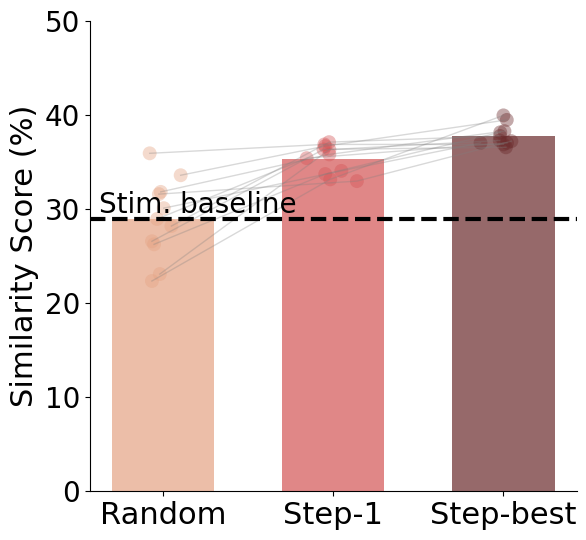

/home/ldy/Closed_loop_optimizing/Heuristic_generation/plots/bar_performance_clip.png


In [6]:

# Example usage:
if __name__ == "__main__":
    # Example data (replace with your actual data)

    
    colors = ['#e5a383', '#d45455', '#6a2a2b', '#b83f5b', '#f5768d']
    x_labels = ['Random', 'Step-1', 'Step-best']
    
    fig, ax = plot_grouped_results(x_labels, 
                                  xlabel='', 
                                  ylabel='Similarity Score (%)', 
                                  bar_data=final_array.T*100, 
                                  colors=colors, 
                                  ylim=(0, 100), 
                                  n_groups=final_array.T.shape[1],  
                                  save_path=f"/home/ldy/Closed_loop_optimizing/Heuristic_generation/plots/bar_performance_{feature_type}.png")
    print(f"/home/ldy/Closed_loop_optimizing/Heuristic_generation/plots/bar_performance_{feature_type}.png")

In [ ]:
###################### hyper-paramters ######################
batch_size = 32
alpha = 80
total_steps = 30
max_inner_steps = 10
num_inference_steps = 8
guidance_scale = 0.0
# dimension = pipe.unet.config.in_channels * pipe.unet.config.sample_size * pipe.unet.config.sample_size
dimension = 1024
self_improvement_ratio = 0.5
reward_scaling_factor = 100
initial_step_size = 30
decay_rate = 0.1  # 调整衰减率
###################### hyper-paramters ######################
is_train = False
# prompt = 'A yellow reindeer and a blue elephant.'
prompt = ''
########################### utils ###########################
@torch.inference_mode()
def latents_to_images(latents):
    shift_factor = pipe.vae.config.shift_factor if pipe.vae.config.shift_factor else 0.0
    latents = (latents / pipe.vae.config.scaling_factor) + shift_factor
    images = pipe.vae.decode(latents, return_dict=False)[0]
    images = pipe.image_processor.postprocess(images)
    return images

def x_flatten(x):
    return einops.rearrange(x, '... C W H -> ... (C W H)', C=pipe.unet.config.in_channels, W=pipe.unet.config.sample_size, H=pipe.unet.config.sample_size)
def x_unflatten(x):
    return einops.rearrange(x, '... (C W H) -> ... C W H', C=pipe.unet.config.in_channels, W=pipe.unet.config.sample_size, H=pipe.unet.config.sample_size)
def get_norm(epsilon):
    return x_flatten(epsilon).norm(dim=-1)[:,:,None,None,None]
def merge_images_grid(image_grid):
    # Assuming image_grid is a 2D list: [[img00, img01, ...], [img10, img11, ...], ...]
    rows = len(image_grid)
    cols = len(image_grid[0])

    # Assume all images are the same size
    img_width, img_height = image_grid[0][0].size

    # Create a new blank image with correct total size
    merged_image = Image.new('RGB', (cols * img_width, rows * img_height))

    for row_idx, row in enumerate(image_grid):
        for col_idx, img in enumerate(row):
            merged_image.paste(img, (col_idx * img_width, row_idx * img_height))

    return merged_image

generator = torch.Generator(device="cuda").manual_seed(0)
########################### utils ###########################


pseudo_target_model = PseudoTargetModel(dimension=dimension, noise_level=1e-4, model_type=model_type) 
pseudo_target_model = pseudo_target_model.to("cuda")

generate_batch_size = 3
save_per = 5

# print(f"data_x {data_x.shape}")
# print(f"data_y {data_y.shape}")   #data_x torch.Size([50, 1024])  data_y torch.Size([50])

pseudo_target_model.add_model_data(data_x, data_y)
epsilon = torch.randn(num_inference_steps+1, generate_batch_size, pipe.unet.config.in_channels, pipe.unet.config.sample_size, pipe.unet.config.sample_size, device="cuda", generator=generator)


epsilon_init = epsilon.clone()
epsilon_init_norm = get_norm(epsilon_init)
all_images = []
# print(f"epsilon {epsilon[1:].shape}")
pipe.load_ip_adapter(
    "h94/IP-Adapter", subfolder="sdxl_models", 
    weight_name="ip-adapter_sdxl_vit-h.bin", 
    torch_dtype=torch.bfloat16)
pipe.set_ip_adapter_scale(0.5)

pseudo_target = torch.randn(generate_batch_size, 1024, device="cuda", generator=generator)


for step in range(total_steps):
    latents = pipe(
        [prompt]*generate_batch_size,
        ip_adapter_image_embeds = [pseudo_target.unsqueeze(0).type(torch.bfloat16).to(device)],
        latents=epsilon[0].type(torch.bfloat16),
        given_noise=epsilon[1:].type(torch.bfloat16),
        output_type="latent",
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        eta=1.0,
        ).images
    
    
    images = latents_to_images(latents)    
    image_inputs = torch.stack([preprocess_train(img) for img in images])    
    with torch.no_grad():
        image_features = vlmodel.encode_image(image_inputs.to(device))
    
    scaled_similarity = reward_function_clip_embed(image_features, tar_image_embed.expand(generate_batch_size, 1024)) * reward_scaling_factor    
    step_size = initial_step_size / (1 + decay_rate * step)    
    # print(f"image_features {image_features.shape}")
    pseudo_target = pseudo_target_model.estimate_pseudo_target(image_features, step_size=step_size)        
    

    if step % save_per == 0:
        print(f"scaled_similarity {scaled_similarity}")
        # all_images.append(images)
    
    for sample_idx in range(generate_batch_size):    
        # Save the first image
        img_to_save = images[sample_idx]
            
        # Save with step and sample index in filename
        img_path = os.path.join(output_dir, f"step_{step}_sample_{sample_idx}.png")
        img_to_save.save(img_path)
        print(f"Saved: {img_path}")
        

In [ ]:
###################### hyper-paramters ######################
batch_size = 32
alpha = 80
total_steps = 30
max_inner_steps = 10
num_inference_steps = 8
guidance_scale = 0.0
# dimension = pipe.unet.config.in_channels * pipe.unet.config.sample_size * pipe.unet.config.sample_size
dimension = 1024
self_improvement_ratio = 0.5
reward_scaling_factor = 100
initial_step_size = 30
decay_rate = 0.1  # 调整衰减率
###################### hyper-paramters ######################
is_train = False
# prompt = 'A yellow reindeer and a blue elephant.'
prompt = ''
########################### utils ###########################
@torch.inference_mode()
def latents_to_images(latents):
    shift_factor = pipe.vae.config.shift_factor if pipe.vae.config.shift_factor else 0.0
    latents = (latents / pipe.vae.config.scaling_factor) + shift_factor
    images = pipe.vae.decode(latents, return_dict=False)[0]
    images = pipe.image_processor.postprocess(images)
    return images

def x_flatten(x):
    return einops.rearrange(x, '... C W H -> ... (C W H)', C=pipe.unet.config.in_channels, W=pipe.unet.config.sample_size, H=pipe.unet.config.sample_size)
def x_unflatten(x):
    return einops.rearrange(x, '... (C W H) -> ... C W H', C=pipe.unet.config.in_channels, W=pipe.unet.config.sample_size, H=pipe.unet.config.sample_size)
def get_norm(epsilon):
    return x_flatten(epsilon).norm(dim=-1)[:,:,None,None,None]
def merge_images_grid(image_grid):
    # Assuming image_grid is a 2D list: [[img00, img01, ...], [img10, img11, ...], ...]
    rows = len(image_grid)
    cols = len(image_grid[0])

    # Assume all images are the same size
    img_width, img_height = image_grid[0][0].size

    # Create a new blank image with correct total size
    merged_image = Image.new('RGB', (cols * img_width, rows * img_height))

    for row_idx, row in enumerate(image_grid):
        for col_idx, img in enumerate(row):
            merged_image.paste(img, (col_idx * img_width, row_idx * img_height))

    return merged_image

generator = torch.Generator(device="cuda").manual_seed(0)
########################### utils ###########################


pseudo_target_model = PseudoTargetModel(dimension=dimension, noise_level=1e-4, model_type=model_type) 
pseudo_target_model = pseudo_target_model.to("cuda")

generate_batch_size = 3
save_per = 5

# print(f"data_x {data_x.shape}")
# print(f"data_y {data_y.shape}")   #data_x torch.Size([50, 1024])  data_y torch.Size([50])

pseudo_target_model.add_model_data(data_x, data_y)
epsilon = torch.randn(num_inference_steps+1, generate_batch_size, pipe.unet.config.in_channels, pipe.unet.config.sample_size, pipe.unet.config.sample_size, device="cuda", generator=generator)


epsilon_init = epsilon.clone()
epsilon_init_norm = get_norm(epsilon_init)
all_images = []
# print(f"epsilon {epsilon[1:].shape}")
pipe.load_ip_adapter(
    "h94/IP-Adapter", subfolder="sdxl_models", 
    weight_name="ip-adapter_sdxl_vit-h.bin", 
    torch_dtype=torch.bfloat16)
pipe.set_ip_adapter_scale(0.5)

pseudo_target = torch.randn(generate_batch_size, 1024, device="cuda", generator=generator)


for step in range(total_steps):
    latents = pipe(
        [prompt]*generate_batch_size,
        ip_adapter_image_embeds = [pseudo_target.unsqueeze(0).type(torch.bfloat16).to(device)],
        latents=epsilon[0].type(torch.bfloat16),
        given_noise=epsilon[1:].type(torch.bfloat16),
        output_type="latent",
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        eta=1.0,
        ).images
    
    
    images = latents_to_images(latents)    
    image_inputs = torch.stack([preprocess_train(img) for img in images])    
    with torch.no_grad():
        image_features = vlmodel.encode_image(image_inputs.to(device))
    
    scaled_similarity = reward_function_clip_embed(image_features, tar_image_embed.expand(generate_batch_size, 1024)) * reward_scaling_factor    
    step_size = initial_step_size / (1 + decay_rate * step)    
    # print(f"image_features {image_features.shape}")
    pseudo_target = pseudo_target_model.estimate_pseudo_target(image_features, step_size=step_size)        
    

    if step % save_per == 0:
        print(f"scaled_similarity {scaled_similarity}")
        # all_images.append(images)
    
    for sample_idx in range(generate_batch_size):    
        # Save the first image
        img_to_save = images[sample_idx]
            
        # Save with step and sample index in filename
        img_path = os.path.join(output_dir, f"step_{step}_sample_{sample_idx}.png")
        img_to_save.save(img_path)
        print(f"Saved: {img_path}")
        